In [1]:
import os

import psycopg2
import matplotlib
import numpy as np
import pandas as pd
import FinanceDataReader as fdr
import matplotlib.dates as mdates

from scipy import stats
from itertools import product
from scipy.interpolate import pchip_interpolate
from Scripts.load_portfolio import get_idiosyncratic_ids
from Library.Random import RandomMT19937
from Library.StatisticsMC import StatisticsMCQuantile, StatisticsMCConfidenceInterval

import arviz as az
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import StrMethodFormatter

az.style.use("arviz-darkgrid")

ModuleNotFoundError: No module named 'Scripts'

In [181]:
valuation_beg_dt = '20250331'
valuation_end_dt = '20250416'
date_format = '%Y%m%d'
valuation_window = pd.bdate_range(pd.to_datetime(arg=valuation_beg_dt, format=date_format), pd.to_datetime(arg=valuation_end_dt, format=date_format))
valuation_window_str = [dt.strftime(date_format) for dt in valuation_window]

lookback_period = 252

systematic_id = '^SPX'
id_dict = {'systematic_id': systematic_id, 'idiosyncratic_ids': get_idiosyncratic_ids()}

systematic_price_ts = fdr.DataReader(id_dict['systematic_id'])['Adj Close']
systematic_price_ts.name = id_dict['systematic_id']
systematic_price_ts.index.name = 'sVALUATION_DATE'

price_ts = []
for symbol in id_dict['idiosyncratic_ids']:
    tmp_df = fdr.DataReader(symbol)['Adj Close']
    tmp_df.name = symbol
    tmp_df.index.name = 'sVALUATION_DATE'
    price_ts.append(tmp_df)

price_ts = pd.concat(price_ts, axis=1)
price_ts = pd.concat([systematic_price_ts, price_ts], axis=1).ffill().bfill()
price_ts.index = pd.to_datetime(price_ts.index)

In [3]:
os.path.abspath(os.path.join(os.getcwd(), '..'))

'/home/bot0001/PycharmProjects/mkt-depth-n-resiliency/Study'

In [182]:
# load what-if scenarios
what_if_scenarios_df = pd.read_csv(os.path.join(os.path.abspath(os.path.join(os.path.abspath(os.path.join(os.getcwd(), '..')), '..')), r'Scripts/Scenarios/what_if_scenarios.csv'))
what_if_scenarios_df = what_if_scenarios_df.set_index('sSCENARIO')
what_if_scenarios_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 245 entries, SCEN_1 to SCEN_245
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dGAMMAI  245 non-null    float64
 1   dBETAI   245 non-null    float64
 2   dRHOIX   245 non-null    float64
dtypes: float64(3)
memory usage: 7.7+ KB


In [235]:
# load current PVs
pv_curr_df = []
valuation_date_list = ['20250403', '20250409']
# valuation_date_list = [dt.strftime('%Y%m%d') for dt in pd.bdate_range(start='20250402', end='20250416')]

if __name__=='__main__':
    import multiprocessing
    from concurrent.futures import ProcessPoolExecutor
    multiprocessing.set_start_method("fork", force=True)

    for date in valuation_date_list:

        path = os.path.join(os.getcwd(), rf"CurrentPV/{date}")
        file_list = [os.path.join(path, f"{file}") for file in os.listdir(path)]

        with ProcessPoolExecutor() as executor:

            results = executor.map(pd.read_pickle, file_list)

            for result in results:
                pv_curr_df.append(pd.DataFrame(result))

index_names = ['sVALUATION_DATE', 'sID', 'sTYPOLOGY', 'sSTRATEGY', 'sPAYOFF', 'sEXPIRY_DATE', 'dSTRIKE_PRICE']
pv_curr_df = pd.concat(pv_curr_df).set_index(index_names)
pv_curr_df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 24 entries, ('20250403', 'COIN', 'asian discrete', 'collar', 'put', '20250417', np.float64(172.23)) to ('20250409', 'COIN', 'vanilla', 'vanilla', 'call', '20250417', np.float64(206.67))
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sSCENARIO           0 non-null      object 
 1   iSCENARIO_NO        24 non-null     int64  
 2   sRETURN_ASSUMPTION  0 non-null      object 
 3   iEXPIRY             24 non-null     int64  
 4   iRISK_HORIZON       24 non-null     int64  
 5   iQUANTITY           24 non-null     int64  
 6   dSPOT_PRICE         24 non-null     float64
 7   dSPOT_SHOCK         24 non-null     float64
 8   dIMP_VOLATILITY     24 non-null     float64
 9   dPV                 24 non-null     object 
dtypes: float64(3), int64(4), object(3)
memory usage: 3.3+ KB


In [236]:
# load scenarios PVs for term structure comparison (i.e., SCEN_0)
pv_scen_df = []

if __name__=='__main__':
    import multiprocessing
    from concurrent.futures import ProcessPoolExecutor
    multiprocessing.set_start_method("fork", force=True)

    for date in valuation_date_list:
        # print(date)
        path = os.path.join(os.getcwd(), rf"ScenarioPV/{date}")
        file_list = [os.path.join(path, f"{file}") for file in os.listdir(path) if ('SCEN_0' in file) & ('LA' in file)]

        with ProcessPoolExecutor() as executor:

            results = executor.map(pd.read_pickle, file_list)

            for result in results:
                pv_scen_df.append(pd.DataFrame(result))

pv_scen_df = pd.concat(pv_scen_df)

index_names = ['sVALUATION_DATE', 'sID', 'sTYPOLOGY', 'sSTRATEGY', 'sPAYOFF', 'sEXPIRY_DATE', 'dSTRIKE_PRICE', 'sSCENARIO', 'iSCENARIO_NO', 'iRISK_HORIZON', 'sRETURN_ASSUMPTION']
pv_scen_df = pv_scen_df.set_index(index_names)

pv_scen_df.info()

20250403
20250409
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 800000 entries, ('20250403', 'COIN', 'asian discrete', 'collar', 'put', '20250417', np.float64(172.23), 'SCEN_0', np.int64(0), np.int64(5), 'LA') to ('20250409', 'COIN', 'vanilla', 'vanilla', 'call', '20250417', np.float64(206.67), 'SCEN_0', np.int64(9999), np.int64(7), 'LA')
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   iEXPIRY          800000 non-null  int64  
 1   iQUANTITY        800000 non-null  int64  
 2   dSPOT_PRICE      800000 non-null  float64
 3   dSPOT_SHOCK      800000 non-null  float64
 4   dIMP_VOLATILITY  800000 non-null  float64
 5   dPV              800000 non-null  object 
dtypes: float64(3), int64(2), object(1)
memory usage: 46.1+ MB


In [237]:
# calculate delta
mask = pv_curr_df.dSPOT_SHOCK==.01
pv_up_df = pv_curr_df.loc[mask].copy()
mask = pv_curr_df.dSPOT_SHOCK==-.01
pv_dn_df = pv_curr_df.loc[mask].copy()
greeks_delta_df = (pv_up_df.dPV - pv_dn_df.dPV) / (pv_up_df.dSPOT_SHOCK * pv_up_df.dSPOT_PRICE * pv_up_df.iQUANTITY.apply(abs)) * .5
greeks_delta_df.name = 'dDELTA'

In [238]:
# filter out pv at T0
mask = pv_curr_df.dSPOT_SHOCK==0.
pv_df = pv_curr_df.loc[mask].copy()

In [239]:
pl_df = pv_scen_df.join(pv_df[['dSPOT_PRICE', 'dPV']], rsuffix='_T0').join(greeks_delta_df)
pl_df['dDELTA_PL'] = pl_df.dDELTA * pl_df.dSPOT_PRICE_T0 * pl_df.dSPOT_SHOCK * pl_df.iQUANTITY.apply(np.abs)
pl_df['dPL'] = (pl_df.dPV - pl_df.dPV_T0) - pl_df.dDELTA_PL

In [240]:
pl_grouped_df = pl_df.pivot_table(index=['sVALUATION_DATE', 'sRETURN_ASSUMPTION', 'iRISK_HORIZON', 'sSCENARIO', 'iSCENARIO_NO', 'dSPOT_SHOCK'], values='dPL', aggfunc='sum')
pl_grouped_df

dPL
sVALUATION_DATE sRETURN_ASSUMPTION iRISK_HORIZON sSCENARIO iSCENARIO_NO dSPOT_SHOCK            
20250403        LA                 1             SCEN_0    0            -0.001169     -0.250302
                                                           1             0.063948    -70.970955
                                                           2             0.029689    -17.639031
                                                           3             0.089873   -121.926218
                                                           4             0.007289     -0.766251
...                                                                                         ...
20250409        LA                 10            SCEN_0    9995         -0.096331    -196.47655
                                                           9996         -0.042980    -35.582236
                                                           9997         -0.010285     -1.337007
                                                           9998          0.114624     30.420997
                                                           9999         -0.050954    -51.038442

[200000 rows x 1 columns]

In [251]:
alpha = 1
stats_quantile_obj = StatisticsMCQuantile(alpha=np.array(alpha / 100))
stats_confidence_interval_obj = StatisticsMCConfidenceInterval()


def stats_mc_quantile_helper(args: tuple) -> tuple:
    valuation_date, risk_horizon, scenario = args
    stats_quantile_obj.dump_result(pl_grouped_df.xs(args).to_numpy())
    return valuation_date, risk_horizon, scenario, stats_quantile_obj.get_result_so_far()[0,0]


def stats_mc_confidence_interval(args: tuple) -> tuple:
    risk_horizon, scenario = args
    stats_confidence_interval_obj.dump_result(pl_grouped_df.xs((risk_horizon, scenario)).to_numpy())
    return risk_horizon, scenario, stats_confidence_interval_obj.get_result_so_far().squeeze()


def bootstrap_var(args: tuple) -> dict:
    rng_gen = RandomMT19937(seed=np.uint64(20240114))

    t, ra, h = args
    pl_vector = pl_grouped_df.xs((t, ra, h)).to_numpy()

    bootstrap_vec = []

    for _ in range(10_000):
        sample = rng_gen.generator.choice(10_000, size=10_000, replace=True)
        stats_quantile_obj.dump_result(pl_vector[sample])
        bootstrap_vec.append(-stats_quantile_obj.get_result_so_far()[0, 0])

    rng_gen.reset()

    return {'sVALUATION_DATE': t, 'sRETURN_ASSUMPTION': ra, 'iRISK_HORIZON': h, 'iSCENARIO_NO': range(10_000), 'dVaR_BOOTSTRAPED': np.array(bootstrap_vec)}


def bootstrap_ci(args: tuple) -> dict:
    rng_gen = RandomMT19937(seed=np.uint64(20240114))

    t, ra, h = args
    pl_vector = pl_grouped_df.xs((t, ra, h)).to_numpy()

    bootstrap_vec = []

    for _ in range(10_000):
        sample = rng_gen.generator.choice(10_000, size=10_000, replace=True)
        stats_quantile_obj.dump_result(pl_vector[sample])
        bootstrap_vec.append(-stats_quantile_obj.get_result_so_far()[0, 0])

    rng_gen.reset()

    ci_lower, ci_upper = (np.quantile(bootstrap_vec, 1-.975), np.quantile(bootstrap_vec, .975))

    bootstrap_df.append((t, ra, h, ci_lower, ci_upper))

    return {'sVALUATION_DATE': t, 'sRETURN_ASSUMPTION': ra, 'iRISK_HORIZON': h, 'dCI_LOWER': float(ci_lower), 'dCI_UPPER': float(ci_upper)}

In [267]:
dates_list_to_compare = valuation_date_list
return_assumptions = ["LA"]
# return_assumptions = ["BS", "LA"]
risk_horizons = pl_grouped_df.index.get_level_values('iRISK_HORIZON').unique()

bootstrap_df = []
bootstrap_ci_df = []

if __name__=='__main__':
    import multiprocessing
    from concurrent.futures import ProcessPoolExecutor
    multiprocessing.set_start_method("fork", force=True)

    with ProcessPoolExecutor() as executor:

        results1 = executor.map(bootstrap_var, product(dates_list_to_compare, return_assumptions, risk_horizons))
        results2 = executor.map(bootstrap_ci, product(dates_list_to_compare, return_assumptions, risk_horizons))

        for result1 in results1:
            bootstrap_df.append(pd.DataFrame(result1))

        for result2 in results2:
            bootstrap_ci_df.append(result2)

bootstrap_df = pd.concat(bootstrap_df)
bootstrap_ci_df = pd.DataFrame(bootstrap_ci_df)
bootstrap_df = bootstrap_df.set_index(['sVALUATION_DATE', 'sRETURN_ASSUMPTION', 'iRISK_HORIZON', 'iSCENARIO_NO'])
bootstrap_ci_df = bootstrap_ci_df.set_index(['sVALUATION_DATE', 'sRETURN_ASSUMPTION', 'iRISK_HORIZON'])
bootstrap_ci_df

KeyError: "None of ['iSCENARIO_NO'] are in the columns"

In [271]:
# calculate quantile for each tuple, (risk horizon, scenario)
risk_horizons_range = np.linspace(1, 10, 10, dtype=int)
quantile_values_list = []
quantile_values_keys = pl_grouped_df.reset_index().set_index(['sVALUATION_DATE', 'sRETURN_ASSUMPTION', 'iRISK_HORIZON']).index.unique()

if __name__=='__main__':
    import multiprocessing
    from concurrent.futures import ProcessPoolExecutor
    multiprocessing.set_start_method("fork", force=True)

    with ProcessPoolExecutor() as executor:

        results = executor.map(stats_mc_quantile_helper, quantile_values_keys)

        for result in results:
            t, ra, h, value = result
            quantile_values_list.append((t, ra, h, -value))

quantile_values_df = pd.DataFrame(quantile_values_list, columns=['sVALUATION_DATE', 'sRETURN_ASSUMPTION', 'iRISK_HORIZON', 'dVaR'])
quantile_values_df = quantile_values_df.set_index(['sVALUATION_DATE', 'sRETURN_ASSUMPTION', 'iRISK_HORIZON'])
quantile_values_df.sort_index(inplace=True)
quantile_values_df = quantile_values_df.join(bootstrap_ci_df)

In [244]:
quantile_values_tmp_df = quantile_values_df.xs(1, level='iRISK_HORIZON').pivot_table(index='sVALUATION_DATE', columns='sRETURN_ASSUMPTION', values='dVaR')
quantile_values_tmp_df['dDIFFERENCE'] = quantile_values_tmp_df.LA.subtract(quantile_values_tmp_df.BS)
quantile_values_tmp_df.round(2)

AttributeError: 'DataFrame' object has no attribute 'BS'

In [245]:
# t-statistics on Bootstrapped VaR
bootstrap_tmp_df = bootstrap_df.xs(1, level='iRISK_HORIZON').pivot_table(index=['sVALUATION_DATE', 'iSCENARIO_NO'], columns='sRETURN_ASSUMPTION', values='dVaR_BOOTSTRAPED').copy()
bootstrap_tmp_df['dDIFFERENCE'] = bootstrap_tmp_df.LA.subtract(bootstrap_tmp_df.BS)

n = bootstrap_tmp_df.xs(valuation_date_list[0]).shape[0]
sample_avg = bootstrap_tmp_df['dDIFFERENCE'].groupby(level='sVALUATION_DATE').mean()
sample_std = bootstrap_tmp_df['dDIFFERENCE'].groupby(level='sVALUATION_DATE').std(ddof=1)
std_error = sample_std / np.sqrt(n)

t_stats = (sample_avg - 0.) / std_error
t_pval = stats.t.sf(np.abs(t_stats), n-1) * 2
pd.DataFrame(data={'dT_STATS': t_stats, 'dT_PVAL': t_pval}).round(2)

AttributeError: 'DataFrame' object has no attribute 'BS'

In [272]:
# term-structure of VaR
risk_horizons_range = np.linspace(1., 10., 10, dtype=int)

tmp_df = pd.DataFrame(index=tuple(product(valuation_date_list, return_assumptions, risk_horizons_range)))
tmp_df.index.names = ['sVALUATION_DATE', 'sRETURN_ASSUMPTION', 'iRISK_HORIZON']
tmp_df['dVaR'] = 0.

for valuation_date, ra in product(valuation_date_list, return_assumptions):
    risk_horizon_vector, var, ci_lower, ci_upper = quantile_values_df.xs((valuation_date, ra)).reset_index().to_numpy().T
    tmp_df.loc[(valuation_date, ra), ['dVaR', 'dCI_LOWER', 'dCI_UPPER']] = pchip_interpolate(xi=risk_horizon_vector, yi=np.vstack((var, ci_lower, ci_upper)).T, x=risk_horizons_range)

tmp_df = pd.melt(tmp_df.reset_index(), id_vars=['sVALUATION_DATE', 'sRETURN_ASSUMPTION', 'iRISK_HORIZON'], var_name='sRISK_DESC', value_name='dRISK')
tmp_df.set_index(['sVALUATION_DATE', 'sRETURN_ASSUMPTION'], inplace=True)

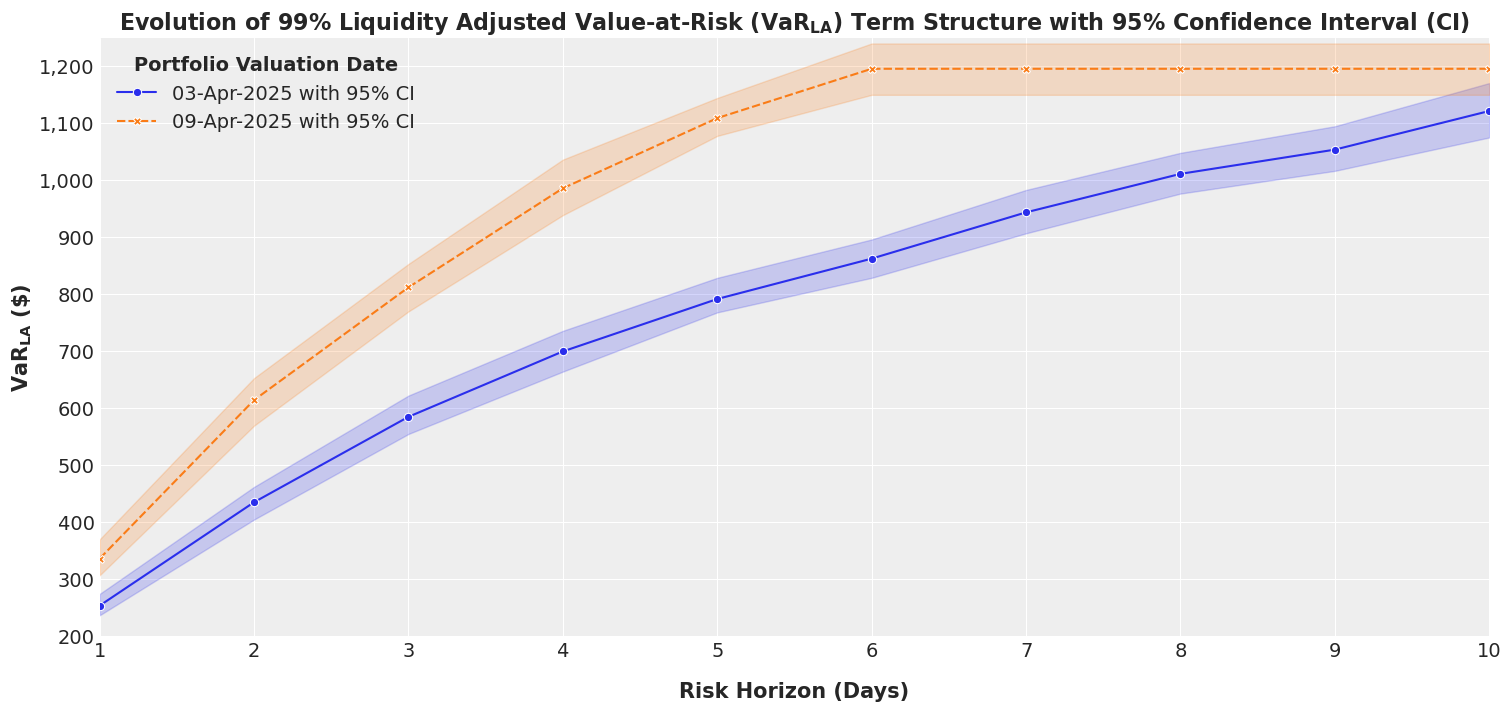

In [273]:
# plot the term-structure of VaRs
fig, ax = plt.subplots(figsize=(15, 7))

mask  = tmp_df.index.get_level_values('sVALUATION_DATE').isin(['20250403', '20250409'])
mask &= tmp_df.index.get_level_values('sRETURN_ASSUMPTION')=='LA'

sns.lineplot(data=tmp_df.loc[mask].reset_index(), x='iRISK_HORIZON', y='dRISK', hue='sVALUATION_DATE', style='sVALUATION_DATE', markers=True, dashes=True, ax=ax)

ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(100))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(1))

ax.yaxis.set_major_formatter('{x:,.0f}')

ax.set_ylabel(rf'$\mathbf{{VaR_{{LA}}}}$ (\$)', fontweight='bold')
ax.set_xlabel('Risk Horizon (Days)', fontweight='bold', labelpad=15)

ax.set_title(rf'Evolution of 99% Liquidity Adjusted Value-at-Risk ($\mathbf{{VaR_{{LA}}}}$) Term Structure with 95% Confidence Interval (CI)', fontweight='bold', fontsize='16')

plt.xlim(1, 10)
plt.ylim(tmp_df.loc[mask].dRISK.min() // 50 * 50, int(np.ceil(tmp_df.loc[mask].dRISK.max() / 50.0)) * 50)

# Create FontProperties object for bold legend text
# legend_font = matplotlib.font_manager.FontProperties(size='14', weight='bold')
handles, labels = ax.get_legend_handles_labels()
labels = [pd.to_datetime(label).strftime('%d-%b-%Y') + ' with 95% CI' for label in labels]

legend = ax.legend()
legend.get_texts()[0].set_text(labels[0])
legend.get_texts()[1].set_text(labels[1])
legend.set_title(title='Portfolio Valuation Date', prop={'size': '14', 'weight': 'bold'})

plt.savefig("term_structure_of_var.pdf", dpi=300)

plt.show();

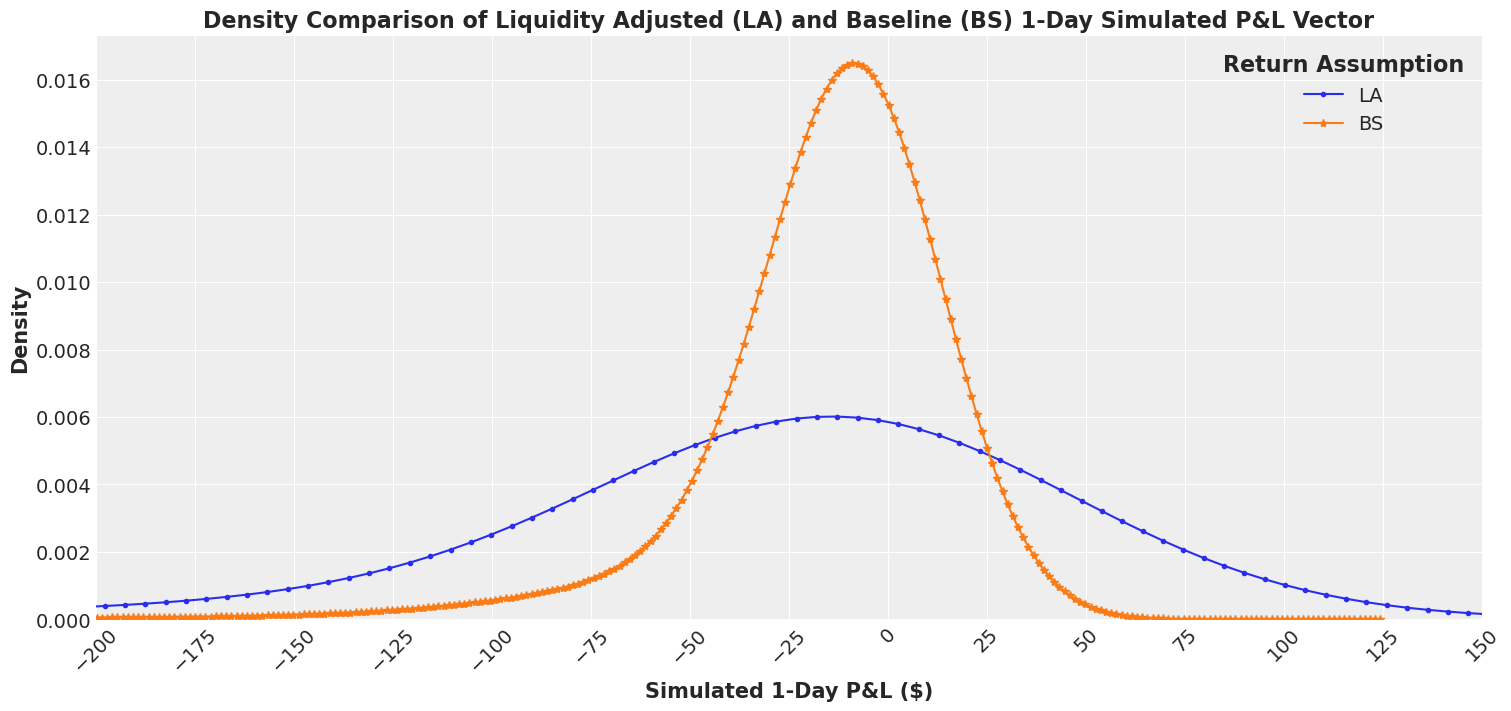

In [160]:
simulated_returns_df = pl_grouped_df.xs(('20250409', 1), level=('sVALUATION_DATE', 'iRISK_HORIZON'))

fig, ax = plt.subplots(figsize=(15, 7))

sns.kdeplot(data=simulated_returns_df.xs('LA'), x='dPL', fill=False, gridsize=500, bw_adjust=5., marker='.', label='LA', ax=ax)
sns.kdeplot(data=simulated_returns_df.xs('BS'), x='dPL', fill=False, gridsize=500, bw_adjust=5., marker='*', label='BS', ax=ax)

ax.set_title(rf'Density Comparison of Liquidity Adjusted (LA) and Baseline (BS) 1-Day Simulated P&L Vector', fontweight='bold')
ax.set_xlabel(r'Simulated 1-Day P&L ($)', fontweight='bold')
ax.set_ylabel("Density", fontweight='bold')
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(25 ))
ax.tick_params(axis='x', labelrotation = 45)

legend = ax.legend()
legend.set_title(title='Return Assumption', prop={'size': '14', 'weight': 'bold'})
plt.setp(ax.get_legend().get_title(), fontsize='16', fontweight='bold')

plt.xlim(-200, 150)
plt.savefig("simulated_pl.pdf", dpi=300)
plt.show();

In [162]:
dates = ['20250402', '20250403', '20250409', valuation_date_list[-2]]

try:
    conn = psycopg2.connect(
        dbname="postgres",
        user="postgres",
        password="postgres",
        host="localhost",
        port="5432"
    )
    print("Database connected successfully")

    select_query = f"SELECT * FROM portfolio;"

    pos_df = pd.read_sql(select_query, con=conn)

except psycopg2.OperationalError as e:
    print(f"Database not connected successfully: {e}")

finally:
    conn.close()
    print("Database connection closed")

Database connected successfully
Database connection closed


/tmp/ipykernel_1318899/2351308254.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pos_df = pd.read_sql(select_query, con=conn)


,svaluation_date,sidiosyncratic_id,stypology,sstrategy,spayoff_type,sexpiry_date,dstrike_price,dposition,sfixing_frequency,sfixing_date_beg,sfixing_date_end,dbase_days
8,20250402,COIN,asian discrete,collar,put,20250417,172.23,-100.0,B,20250331,20250417,252.0
9,20250402,COIN,asian discrete,collar,call,20250417,198.06,100.0,B,20250331,20250417,252.0
10,20250402,COIN,vanilla,vanilla,put,20250417,180.84,85.0,None,None,None,252.0
11,20250402,COIN,vanilla,vanilla,call,20250417,206.67,-120.0,None,None,None,252.0
12,20250403,COIN,asian discrete,collar,put,20250417,172.23,-100.0,B,20250331,20250417,252.0
13,20250403,COIN,asian discrete,collar,call,20250417,198.06,100.0,B,20250331,20250417,252.0
14,20250403,COIN,vanilla,vanilla,put,20250417,180.84,85.0,None,None,None,252.0
15,20250403,COIN,vanilla,vanilla,call,20250417,206.67,-120.0,None,None,None,252.0
28,20250409,COIN,asian discrete,collar,put,20250417,172.23,-100.0,B,20250331,20250417,252.0
29,20250409,COIN,asian discrete,collar,call,20250417,198.06,100.0,B,20250331,20250417,252.0


In [ ]:
fig, ax = plt.subplots(figsize=(15, 7))

underlying_name = SET_OF_TICKERS[-1]
valuation_date = valuation_date_array[0]

spot_price_t0 = prices_df.xs(valuation_date)[underlying_name]
strike_lower_asian = portfolio_pos_dict[valuation_date.strftime("%Y%m%d")]['COIN'][0].dSTRIKE_PRICE
strike_upper_asian = portfolio_pos_dict[valuation_date.strftime("%Y%m%d")]['COIN'][1].dSTRIKE_PRICE
strike_lower_hedge = portfolio_pos_dict[valuation_date.strftime("%Y%m%d")]['COIN'][2].dSTRIKE_PRICE
strike_upper_hedge = portfolio_pos_dict[valuation_date.strftime("%Y%m%d")]['COIN'][3].dSTRIKE_PRICE

dates = [pd.to_datetime('20250402'), pd.to_datetime('20250403'), pd.to_datetime('20250409'), valuation_date_array[-2]]
linestyles = ['-', ':', '-.', '--']

for valuation_date, linestyle in zip(dates, linestyles):
    tmp_df1 = pl_df.loc[
        (pl_df.index.get_level_values('sVALUATION_DATE')==valuation_date.strftime("%Y%m%d")) &
        (pl_df.index.get_level_values('sUNDERLYING')==underlying_name) &
        (pl_df.index.get_level_values('bIS_BASE_SCENARIO')==False),
        ['iSCENARIO_NUM', 'dSPOT_SHIFT', 'dPL', 'dPL_DELTA']
    ]
    tmp_df1.dSPOT_SHIFT = tmp_df1.dSPOT_SHIFT * 100.
    tmp_df1 = tmp_df1.groupby(['iSCENARIO_NUM', 'dSPOT_SHIFT']).sum()
    sns.lineplot(
        data=tmp_df1.reset_index(), x='dSPOT_SHIFT', y='dPL', ax=ax,
        label=rf"{valuation_date.strftime('%b %d')}, $S=\${prices_df.xs(valuation_date)[underlying_name]:.2f}$", linestyle=linestyle)

# tmp_df2 = pl_df.loc[
#     (pl_df.index.get_level_values('sVALUATION_DATE')==valuation_date.strftime("%Y%m%d")) & (pl_df.index.get_level_values('sUNDERLYING')==underlying_name) & (pl_df.index.get_level_values('bIS_BASE_SCENARIO')==True),
#     ['iSCENARIO_NUM', 'dSPOT_SHIFT', 'dPL']
# ]
# tmp_df2.dSPOT_SHIFT = tmp_df2.dSPOT_SHIFT * 100.
# tmp_df2 = tmp_df2.groupby(['iSCENARIO_NUM', 'dSPOT_SHIFT']).sum()
# sns.scatterplot(data=tmp_df2.reset_index(), x='dSPOT_SHIFT', y='dPL', ax=ax, label=r"$\gamma_i = \beta_i = \rho_{i,x} = 0$")

ax.set_xlabel(r'Simulated 1-Day Price Shocks (%)')
ax.set_ylabel('P&L ($)')
ax.set_title("P&L Ladder per Simulated Price Shock", fontweight='bold')

ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(100))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(2))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.tick_params(axis='x', labelrotation = 45)
plt.legend(title='Risk Date, Spot Price (S)', title_fontsize=14)
plt.xlim(-20., 20.)
plt.ylim(-700, 300.)

plt.savefig("pl_ladder.pdf", dpi=300)
plt.show()

In [227]:
# load current PVs
pv_curr_df = []
valuation_date_list = ['20250409']

if __name__=='__main__':
    import multiprocessing
    from concurrent.futures import ProcessPoolExecutor
    multiprocessing.set_start_method("fork", force=True)

    for date in valuation_date_list:

        path = os.path.join(os.getcwd(), rf"CurrentPV/{date}")
        file_list = [os.path.join(path, f"{file}") for file in os.listdir(path)]

        with ProcessPoolExecutor() as executor:

            results = executor.map(pd.read_pickle, file_list)

            for result in results:
                pv_curr_df.append(pd.DataFrame(result))

index_names = ['sVALUATION_DATE', 'sID', 'sTYPOLOGY', 'sSTRATEGY', 'sPAYOFF', 'sEXPIRY_DATE', 'dSTRIKE_PRICE']
pv_curr_df = pd.concat(pv_curr_df).set_index(index_names)
pv_curr_df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 12 entries, ('20250409', 'COIN', 'asian discrete', 'collar', 'put', '20250417', np.float64(172.23)) to ('20250409', 'COIN', 'vanilla', 'vanilla', 'call', '20250417', np.float64(206.67))
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sSCENARIO           0 non-null      object 
 1   iSCENARIO_NO        12 non-null     int64  
 2   sRETURN_ASSUMPTION  0 non-null      object 
 3   iEXPIRY             12 non-null     int64  
 4   iRISK_HORIZON       12 non-null     int64  
 5   iQUANTITY           12 non-null     int64  
 6   dSPOT_PRICE         12 non-null     float64
 7   dSPOT_SHOCK         12 non-null     float64
 8   dIMP_VOLATILITY     12 non-null     float64
 9   dPV                 12 non-null     object 
dtypes: float64(3), int64(4), object(3)
memory usage: 2.3+ KB


In [233]:
# load scenarios PVs for term structure comparison (i.e., SCEN_0)
pv_scen_df = []

if __name__=='__main__':
    import multiprocessing
    from concurrent.futures import ProcessPoolExecutor
    multiprocessing.set_start_method("fork", force=True)

    for date in valuation_date_list:

        path = os.path.join(os.getcwd(), rf"ScenarioPV/{date}")
        file_list = [os.path.join(path, f"{file}") for file in os.listdir(path)]

        with ProcessPoolExecutor() as executor:

            results = executor.map(pd.read_pickle, file_list)

            for result in results:
                pv_scen_df.append(pd.DataFrame(result))

pv_scen_df = pd.concat(pv_scen_df)

index_names = ['sVALUATION_DATE', 'sID', 'sTYPOLOGY', 'sSTRATEGY', 'sPAYOFF', 'sEXPIRY_DATE', 'dSTRIKE_PRICE', 'sSCENARIO', 'iSCENARIO_NO', 'iRISK_HORIZON', 'sRETURN_ASSUMPTION']
pv_scen_df = pv_scen_df.set_index(index_names)

pv_scen_df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 49200000 entries, ('20250409', 'COIN', 'asian discrete', 'collar', 'put', '20250417', np.float64(172.23), 'SCEN_135', np.int64(0), np.int64(3), 'LA') to ('20250409', 'COIN', 'vanilla', 'vanilla', 'call', '20250417', np.float64(206.67), 'SCEN_2', np.int64(9999), np.int64(10), 'LA')
Data columns (total 6 columns):
 #   Column           Dtype  
---  ------           -----  
 0   iEXPIRY          int64  
 1   iQUANTITY        int64  
 2   dSPOT_PRICE      float64
 3   dSPOT_SHOCK      float64
 4   dIMP_VOLATILITY  float64
 5   dPV              object 
dtypes: float64(3), int64(2), object(1)
memory usage: 2.8+ GB


In [234]:
# calculate delta
mask = pv_curr_df.dSPOT_SHOCK==.01
pv_up_df = pv_curr_df.loc[mask].copy()
mask = pv_curr_df.dSPOT_SHOCK==-.01
pv_dn_df = pv_curr_df.loc[mask].copy()
greeks_delta_df = (pv_up_df.dPV - pv_dn_df.dPV) / (pv_up_df.dSPOT_SHOCK * pv_up_df.dSPOT_PRICE * pv_up_df.iQUANTITY.apply(abs)) * .5
greeks_delta_df.name = 'dDELTA'

In [235]:
# filter out pv at T0
mask = pv_curr_df.dSPOT_SHOCK==0.
pv_df = pv_curr_df.loc[mask].copy()

In [236]:
pl_df = pv_scen_df.join(pv_df[['dSPOT_PRICE', 'dPV']], rsuffix='_T0').join(greeks_delta_df)
pl_df['dDELTA_PL'] = pl_df.dDELTA * pl_df.dSPOT_PRICE_T0 * pl_df.dSPOT_SHOCK * pl_df.iQUANTITY.apply(np.abs)
pl_df['dPL'] = (pl_df.dPV - pl_df.dPV_T0) - pl_df.dDELTA_PL

In [237]:
pl_grouped_df = pl_df.pivot_table(index=['sVALUATION_DATE', 'iRISK_HORIZON', 'sSCENARIO', 'iSCENARIO_NO', 'dSPOT_SHOCK'], values='dPL', aggfunc='sum')
pl_grouped_df

dPL
sVALUATION_DATE iRISK_HORIZON sSCENARIO iSCENARIO_NO dSPOT_SHOCK            
20250409        1             SCEN_0    0            -0.001166      0.031805
                                        1             0.064700    -15.735443
                                        2             0.030048    -11.865003
                                        3             0.090923     -0.032132
                                        4             0.007390     -1.037267
...                                                                      ...
                10            SCEN_99   9995         -0.104712   -233.696736
                                        9996         -0.047350     -43.63863
                                        9997         -0.011978     -1.929025
                                        9998          0.124053     47.797437
                                        9999         -0.062334    -78.491098

[12300000 rows x 1 columns]

In [238]:
# calculate quantile for each tuple, (risk horizon, scenario)
risk_horizons_range = np.linspace(1., 10., 10, dtype=int)
quantile_values_list = []
quantile_values_keys = pl_grouped_df.reset_index().set_index(['sVALUATION_DATE', 'iRISK_HORIZON', 'sSCENARIO']).index.unique()

if __name__=='__main__':
    import multiprocessing
    from concurrent.futures import ProcessPoolExecutor
    multiprocessing.set_start_method("fork", force=True)

    with ProcessPoolExecutor() as executor:

        results = executor.map(stats_mc_quantile_helper, quantile_values_keys)

        for result in results:
            t, h, scenario, value = result
            quantile_values_list.append((t, h, scenario, -value))

quantile_values_df = pd.DataFrame(quantile_values_list, columns=['sVALUATION_DATE', 'iRISK_HORIZON', 'sSCENARIO', 'dVaR'])
quantile_values_df = quantile_values_df.set_index(['sVALUATION_DATE', 'iRISK_HORIZON', 'sSCENARIO'])
quantile_values_df.sort_index(inplace=True)

In [246]:
quantile_values_df.loc[quantile_values_df.index.get_level_values('sSCENARIO')!='SCEN_0'].join(what_if_scenarios_df)

dVaR  dGAMMAI  dBETAI  dRHOIX
sVALUATION_DATE iRISK_HORIZON sSCENARIO                                      
20250409        1             SCEN_1      125.424676      0.0     0.0    -1.0
                              SCEN_10     172.147138      0.0     0.5     1.0
                              SCEN_100    426.199235      1.0     2.5     1.0
                              SCEN_101     16.775512      1.0     3.0    -1.0
                              SCEN_102    133.795958      1.0     3.0    -0.5
...                                              ...      ...     ...     ...
                10            SCEN_95    1209.075751      1.0     2.0     1.0
                              SCEN_96     188.000029      1.0     2.5    -1.0
                              SCEN_97     600.282950      1.0     2.5    -0.5
                              SCEN_98     902.153112      1.0     2.5     0.0
                              SCEN_99    1132.972070      1.0     2.5     0.5

[1225 rows x 4 columns]

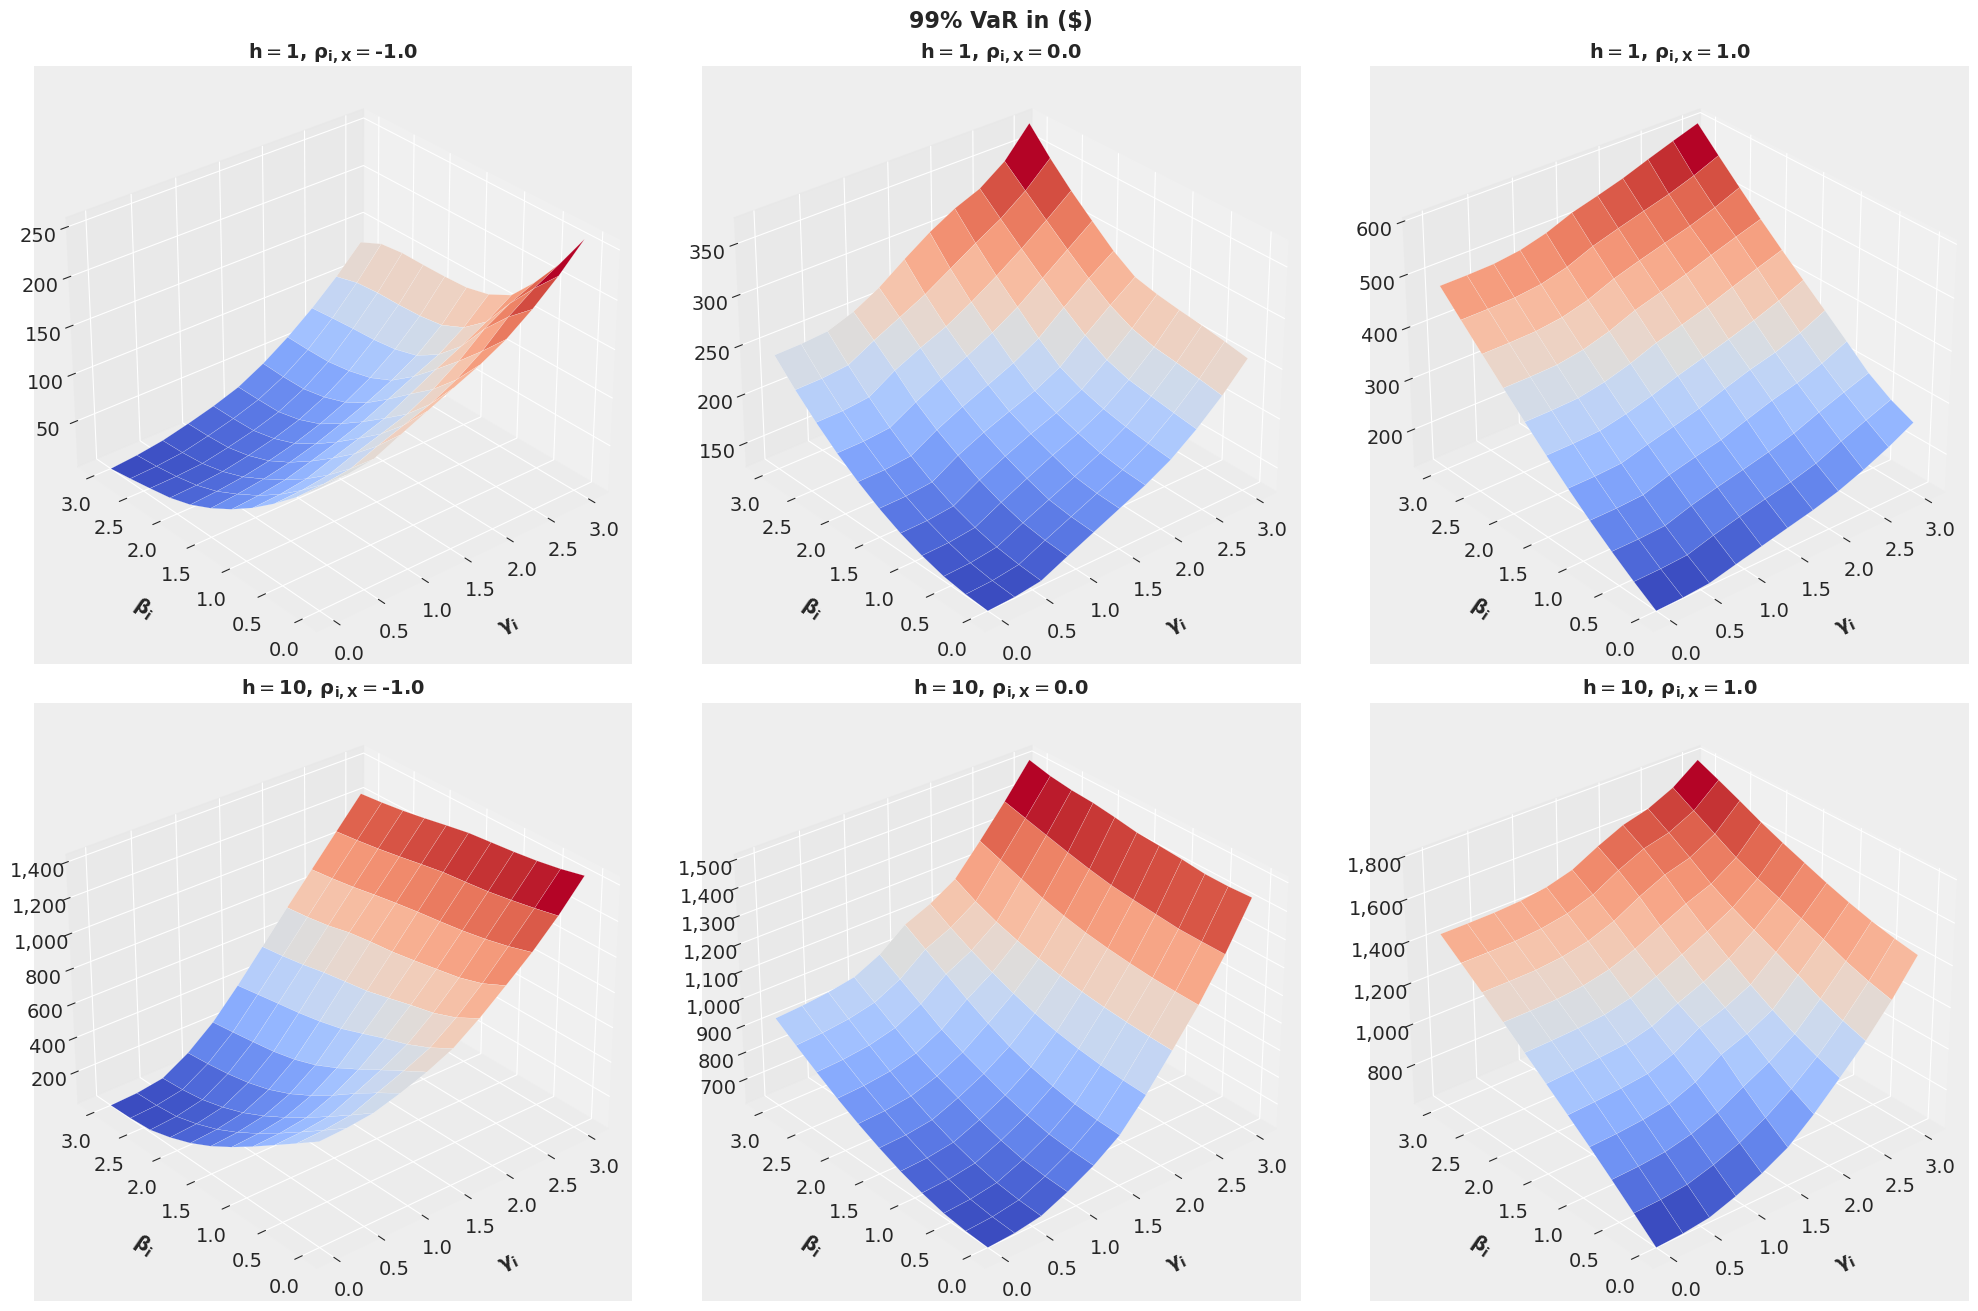

In [362]:
gammai_min = what_if_scenarios_df.dGAMMAI.unique().min()
gammai_max = what_if_scenarios_df.dGAMMAI.unique().max()
gammai_range = np.linspace(gammai_min, gammai_max, 11)

betai_min = what_if_scenarios_df.dBETAI.unique().min()
betai_max = what_if_scenarios_df.dBETAI.unique().max()
betai_range = np.linspace(betai_min, betai_max, 11)

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(20, 13), subplot_kw={'projection': '3d'})

for tup, ax in zip(product([1, 10], [-1, 0, 1]), axs.flatten()):
    h, rhoix = tup
    tmp_quantile_values_df = quantile_values_df.loc[quantile_values_df.index.get_level_values('sSCENARIO')!='SCEN_0'].join(what_if_scenarios_df)
    tmp_quantile_values_subset_df = tmp_quantile_values_df.loc[tmp_quantile_values_df.dRHOIX==rhoix].xs(h, level='iRISK_HORIZON').copy()
    betai_unique = np.sort(tmp_quantile_values_subset_df.dBETAI.unique())

    yi = []
    for betai in betai_unique:
        mask = tmp_quantile_values_subset_df.dBETAI==betai
        loss_vector, gammai_vector = tmp_quantile_values_subset_df.loc[mask, ['dVaR', 'dGAMMAI']].sort_values('dGAMMAI').to_numpy().T
        yi.append(pchip_interpolate(xi=gammai_vector, yi=loss_vector, x=gammai_range))

    Z = pchip_interpolate(xi=betai_unique, yi=np.array(yi), x=betai_range)

    X, Y = np.meshgrid(gammai_range, betai_range)
    ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, linewidth=0.1)

    ax.view_init(30, 50)
    ax.invert_xaxis()
    ax.invert_yaxis()

    ax.set_xlabel(r'$\mathbf{\gamma_i}$', fontweight='bold', labelpad=15, fontsize=14)
    ax.set_ylabel(r'$\mathbf{\beta_i}$', fontweight='bold', labelpad=15, fontsize=14)

    ax.zaxis.set_major_formatter('{x:,.0f}')
    ax.set_zlim(Z.min(), Z.max())

    ax.set_title(rf'$\mathbf{{h}}=${h}, $\mathbf{{\rho_{{i,X}}}}=${rhoix:.1f}', fontweight='bold', fontsize=14)

fig.suptitle('99% VaR in ($)', fontsize=16, fontweight='bold')

plt.savefig("var99_surfs_by_h_varying_gammai_betai_given_rhoix.pdf", dpi=300)
plt.show();

In [364]:
# h = 5
# gammai = 0
#
# rhoix_min = what_if_scenarios_df.dRHOIX.unique().min()
# rhoix_max = what_if_scenarios_df.dRHOIX.unique().max()
# rhoix_range = np.linspace(rhoix_min, rhoix_max, 11)
#
# betai_min = what_if_scenarios_df.dBETAI.unique().min()
# betai_max = what_if_scenarios_df.dBETAI.unique().max()
# betai_range = np.linspace(betai_min, betai_max, 11)
#
# tmp_quantile_values_subset_df = tmp_quantile_values_df.loc[tmp_quantile_values_df.dGAMMAI==gammai].xs(h, level='iRISK_HORIZON').copy()
# betai_unique = np.sort(tmp_quantile_values_subset_df.dBETAI.unique())
#
#
# yi = []
# for betai in betai_unique:
#     loss_vector, xi = tmp_quantile_values_subset_df.loc[tmp_quantile_values_subset_df.dBETAI==betai, ['dVaR', 'dRHOIX']].sort_values('dRHOIX').to_numpy().T
#     yi.append(pchip_interpolate(xi=xi, yi=loss_vector, x=rhoix_range))
#
# Z = pchip_interpolate(xi=betai_unique, yi=np.array(yi), x=betai_range)

In [365]:
# fig = plt.figure(figsize=(10, 7))
#
# ax = fig.add_subplot(111, projection='3d')
# X, Y = np.meshgrid(rhoix_range, betai_range)
#
# ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, linewidth=0.1)
#
# # ax.text(0., 1., 1350, f'{1_350:,.0f}', color='Green', fontsize=16, zorder=10)
#
# ax.view_init(40, 45)
# ax.invert_xaxis()
# # ax.invert_yaxis()
#
# ax.set_xlabel(r'$\rho_{i,X}$', fontweight='bold', labelpad=15, fontsize=16)
# ax.set_ylabel(r'$\beta_i$', fontweight='bold', labelpad=15, fontsize=16)
#
# ax.zaxis.set_major_formatter('{x:,.0f}')
#
# plt.show();